In [2]:
import os
import librosa
import numpy as np
import pandas as pd
from tqdm import tqdm

# --- UPDATED PATHS FOR KAGGLE ---
# Ensure this matches your "Data" tab on the right side of the Kaggle UI
BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup" 
TRAIN_PATH = os.path.join(BASE_PATH, "genres_stems")
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def run_eda():
    results = {
        "jazz_durations": [],
        "sample_rates": set(),
        "corrupted_files": 0,
        "vocal_peaks_db": [],
        "blues_centroids": [],
        "genre_centroids": {g: [] for g in GENRES},
        "silence_count": 0
    }

    print("🔍 Scanning directory structure...")
    
    for genre in GENRES:
        genre_dir = os.path.join(TRAIN_PATH, genre)
        if not os.path.exists(genre_dir):
            continue
            
        # Each genre folder contains song subfolders
        songs = [s for s in os.listdir(genre_dir) if os.path.isdir(os.path.join(genre_dir, s))]
        
        for song in tqdm(songs, desc=f"Processing {genre}"):
            song_path = os.path.join(genre_dir, song)
            
            # The 4 stems we expect
            stems = ["drums.wav", "vocals.wav", "bass.wav", "others.wav"]
            
            for stem in stems:
                file_path = os.path.join(song_path, stem)
                
                # Check if file exists and is not empty
                if not os.path.exists(file_path) or os.path.getsize(file_path) == 0:
                    results["corrupted_files"] += 1
                    continue
                
                try:
                    # Load audio (sr=None preserves original sample rate)
                    y, sr = librosa.load(file_path, sr=None)
                    
                    if len(y) == 0:
                        results["corrupted_files"] += 1
                        continue

                    results["sample_rates"].add(sr)

                    # 1. Jazz Duration
                    if genre == "jazz":
                        results["jazz_durations"].append(len(y) / sr)

                    # 2. Vocal Peaks (dB)
                    if stem == "vocals.wav":
                        peak = np.max(np.abs(y))
                        if peak > 0:
                            db = 20 * np.log10(peak)
                            results["vocal_peaks_db"].append(db)

                    # 3. Spectral Centroid
                    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
                    mean_cent = np.mean(cent)
                    results["genre_centroids"][genre].append(mean_cent)
                    if genre == "blues":
                        results["blues_centroids"].append(mean_cent)

                    # 4. Silence in first 0.5s
                    first_05s = y[:int(0.5 * sr)]
                    if len(first_05s) > 0 and np.max(np.abs(first_05s)) < 1e-4:
                        results["silence_count"] += 1

                except Exception as e:
                    results["corrupted_files"] += 1

    # --- REPORTING ---
    print("\n" + "="*30)
    print("EDA ANSWERS")
    print("="*30)
    
    if results["jazz_durations"]:
        print(f"1. Mean Jazz Duration: {np.mean(results['jazz_durations']):.4f}s")
    
    print(f"2. Unique Sample Rates: {sorted(list(results['sample_rates']))}")
    print(f"3. Corrupted/Zero-byte files: {results['corrupted_files']}")
    
    if results["vocal_peaks_db"]:
        print(f"4. Avg Peak Vocal Amplitude: {np.mean(results['vocal_peaks_db']):.4f} dB")
        
    if results["blues_centroids"]:
        print(f"5. Mean Blues Spectral Centroid: {np.mean(results['blues_centroids']):.4f}")

    # Calculate highest genre centroid
    avg_genre_cents = {g: np.mean(v) for g, v in results["genre_centroids"].items() if v}
    if avg_genre_cents:
        highest_genre = max(avg_genre_cents, key=avg_genre_cents.get)
        print(f"6. Genre with Highest Centroid: {highest_genre}")
        
    print(f"7. Files with silence in first 0.5s: {results['silence_count']}")

run_eda()

🔍 Scanning directory structure...


Processing rock: 100%|██████████| 100/100 [00:58<00:00,  1.70it/s]


EDA ANSWERS
1. Mean Jazz Duration: 30.0330s
2. Unique Sample Rates: [44100]
3. Corrupted/Zero-byte files: 1000
4. Avg Peak Vocal Amplitude: -12.4949 dB
5. Mean Blues Spectral Centroid: 2533.2226
6. Genre with Highest Centroid: jazz
7. Files with silence in first 0.5s: 332


/tmp/ipykernel_119/3508977683.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cl

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



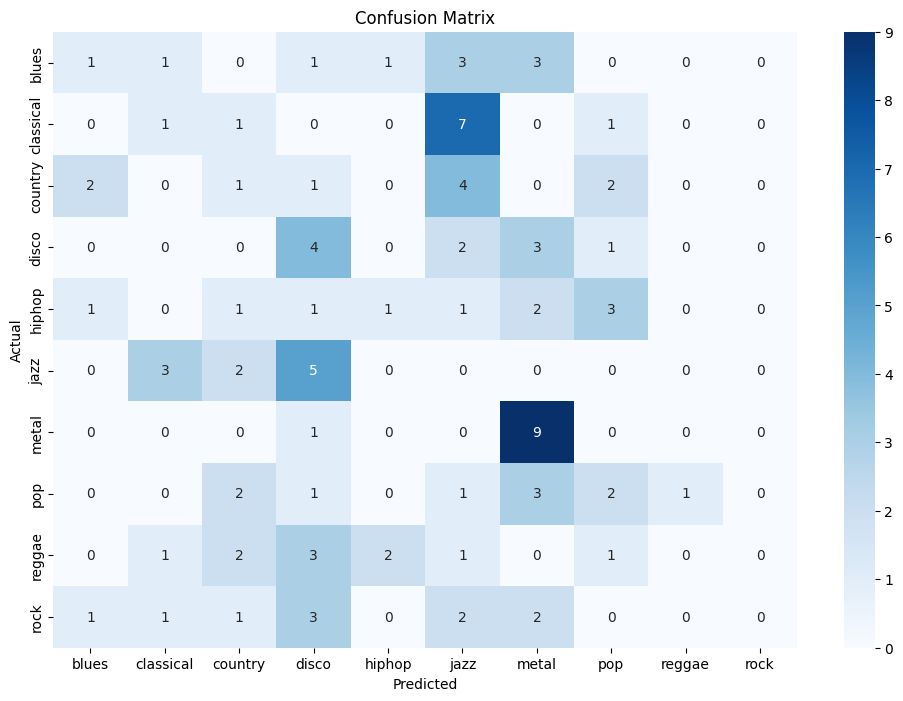


Per-Genre Breakdown:
       Genre  TP  TN  FP  FN
0      blues   1  86   4   9
1  classical   1  84   6   9
2    country   1  81   9   9
3      disco   4  74  16   6
4     hiphop   1  87   3   9
5       jazz   0  69  21  10
6      metal   9  77  13   1
7        pop   2  82   8   8
8     reggae   0  89   1  10
9       rock   0  90   0  10

Model Accuracy: 0.1900
Genre with highest TP: metal
Genre with lowest FN: metal


In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred, target_names=GENRES)


print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

metrics_data = []
for i, genre in enumerate(GENRES):
    tp = cm[i, i]
    fn = np.sum(cm[i, :]) - tp
    fp = np.sum(cm[:, i]) - tp
    tn = np.sum(cm) - (tp + fp + fn)
    metrics_data.append({
        'Genre': genre,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn
    })

metrics_df = pd.DataFrame(metrics_data)
print("\nPer-Genre Breakdown:")
print(metrics_df)

print(f"\nModel Accuracy: {clf.score(X_val, y_val):.4f}")
print(f"Genre with highest TP: {metrics_df.loc[metrics_df['TP'].idxmax(), 'Genre']}")
print(f"Genre with lowest FN: {metrics_df.loc[metrics_df['FN'].idxmin(), 'Genre']}")